In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
pt = PowerTransformer(method='yeo-johnson')
X_std = pt.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.735252,0.067055,0.176922,0.072022,0.104910,-0.000955,-0.190635,-0.021816,0.103330,-0.274204,...,1.042615,-0.340702,-0.305657,0.622355,-0.784694,-0.404309,-0.370546,-0.074611,-0.654022,-0.325914
1,1.029207,-1.298903,-2.046814,-1.421627,-1.344285,-1.500591,-0.993359,-1.453969,-1.512997,-0.807533,...,1.929439,1.907148,0.939011,-1.489676,-0.784694,1.826912,1.188847,1.689445,1.560347,0.852496
2,0.480839,0.581443,0.777497,0.444135,0.593101,0.323069,0.452558,0.617141,0.651680,0.764603,...,-0.799521,0.082511,0.147926,0.741227,0.236612,-0.110511,-1.026597,-1.065926,-0.824361,-0.125568
3,1.080021,-0.986786,-1.714238,-1.314128,-1.459229,-1.636023,-0.469852,-1.044798,-1.371728,-0.684399,...,1.846691,1.751709,0.986180,-1.383365,-0.784694,0.301039,1.216712,-1.065926,1.122247,1.296177
4,0.946400,-0.689355,-0.765790,-0.468644,-0.828545,-0.393167,-0.250949,-0.482649,-0.997043,0.080384,...,-0.799521,0.230152,0.900131,-1.607406,1.784568,1.860059,1.405024,1.782787,1.919501,1.900963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.200607,-0.027337,-0.469576,-0.601731,-0.503317,-0.423114,-0.843152,-0.642530,-0.522668,-0.587170,...,-0.799521,-0.050750,-0.332827,0.301629,-0.784694,-0.811377,0.115613,-1.065926,-0.733951,-0.371465
135,0.368838,1.721586,0.901503,0.002519,0.280704,0.389333,0.314470,0.253816,0.527224,0.286038,...,-0.000653,0.215135,0.445866,-0.027763,-0.784694,0.654869,-0.266178,0.138716,-0.145951,0.659834
136,0.459982,0.996190,0.306773,-0.316986,-0.665131,-0.117023,0.464099,-0.299082,0.050381,0.019889,...,-0.799521,-1.105445,-1.073694,1.149438,-0.784694,-1.222412,-0.358889,-1.065926,-0.928256,0.305804
137,-0.551976,-0.284014,0.183709,0.314722,0.178739,0.095604,0.005239,0.207510,0.224901,0.081128,...,-0.799521,-0.455330,0.120914,-0.137599,-0.784694,0.225798,0.256551,-0.175482,-0.103535,0.868321


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

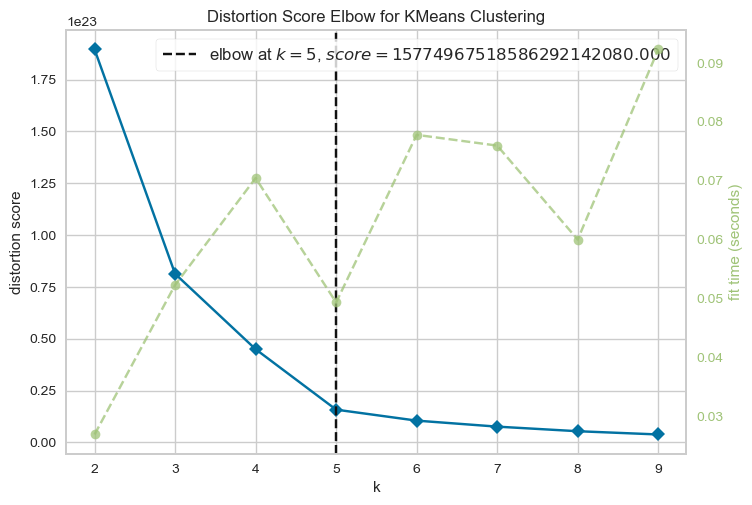

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: glcm_ClusterTendency_d_1_CT_b20, Coefficient: -2.1048569034314677


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: gldm_DependenceNonUniformity_d_1_CT_b20, Coefficient: 3.8354493099655413


...

Cluster 2: Most important feature: glcm_DifferenceAverage_d_1_PET_c04, Coefficient: 4.358521559805524


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glcm_SumEntropy_d_1_PET_b2, Coefficient: -3.5734408693484556


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: first_order_90Percentile_CT, Coefficient: -20168026852048.53


In [22]:
selected_features

['glcm_ClusterTendency_d_1_CT_b20',
 'gldm_DependenceNonUniformity_d_1_CT_b20',
 'glcm_DifferenceAverage_d_1_PET_c04',
 'glcm_SumEntropy_d_1_PET_b2',
 'first_order_90Percentile_CT']

In [23]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

# Yeo-Johnson Transformation

In [24]:
# Do the standardization for X_fs_fi
pt = PowerTransformer(method='yeo-johnson')
X_new_std= pt.fit_transform(X_fs_fi)
X_new_std = pd.DataFrame(X_new_std,
                        columns=X_fs_fi.columns, 
                        index=X_fs_fi.index)

# Do the standardization for MAASTRO 
MAASTRO_new = X_MAASTRO[selected_features]
MAASTRO_new_std = pt.transform(MAASTRO_new)
MAASTRO_new_std = pd.DataFrame(MAASTRO_new_std, 
                              columns=MAASTRO_new.columns, 
                              index=MAASTRO_new.index )

In [25]:
X_new

,glcm_ClusterTendency_d_1_CT_b20,gldm_DependenceNonUniformity_d_1_CT_b20,glcm_DifferenceAverage_d_1_PET_c04,glcm_SumEntropy_d_1_PET_b2,first_order_90Percentile_CT
0,54.573213,895.623289,0.356587,3.754090,1177.917830
1,33.386585,145.120852,0.420129,2.413947,1109.046098
2,40.784508,1409.211873,0.325835,2.533511,1149.884925
3,45.463501,257.557387,0.401664,1.511640,1126.003305
4,52.638118,366.894779,0.510112,2.224460,1134.384047
...,...,...,...,...,...
134,12.108105,433.127389,0.409956,3.078890,1157.360037
135,28.069410,1004.123096,0.321183,2.183687,1126.367132
136,35.905635,611.553583,0.374487,3.491112,1111.612526
137,6.483329,738.677398,0.402135,2.350441,1117.834717


In [26]:
X_new_std

,glcm_ClusterTendency_d_1_CT_b20,gldm_DependenceNonUniformity_d_1_CT_b20,glcm_DifferenceAverage_d_1_PET_c04,glcm_SumEntropy_d_1_PET_b2,first_order_90Percentile_CT
0,0.451170,0.305193,-0.094031,0.945098,8.604228e-16
1,-0.004580,-1.542483,0.595643,-0.690955,-3.885781e-16
2,0.185710,0.762283,-0.468257,-0.560691,3.885781e-16
3,0.286286,-0.958406,0.405940,-1.568480,-5.551115e-17
4,0.418997,-0.598766,1.412495,-0.890843,1.110223e-16
...,...,...,...,...,...
134,-1.063704,-0.430304,0.492151,0.073157,5.273559e-16
135,-0.174678,0.420644,-0.527421,-0.932792,-5.551115e-17
136,0.065319,-0.080638,0.111075,0.594273,-3.330669e-16
137,-1.779936,0.110477,0.410886,-0.758847,-2.220446e-16


In [27]:
MAASTRO_new

,glcm_ClusterTendency_d_1_CT_b20,gldm_DependenceNonUniformity_d_1_CT_b20,glcm_DifferenceAverage_d_1_PET_c04,glcm_SumEntropy_d_1_PET_b2,first_order_90Percentile_CT
0,15.819587,1520.503345,0.335443,3.759350,1103.940398
1,95.515772,795.461212,0.279434,2.672821,1117.575395
2,43.157032,701.785465,0.310763,3.594481,1110.775817
3,390.902346,768.278293,0.301684,2.855404,1191.267456
4,11.504749,1118.860654,0.300615,2.701690,1108.918120
...,...,...,...,...,...
94,69.352879,523.573339,0.327473,4.889258,1132.303273
95,360.715961,951.793787,0.310449,3.155474,1108.789902
96,29.424999,1415.626880,0.264803,2.366946,1107.996338
97,43.230094,1257.067885,0.305581,3.608520,1161.546578


In [28]:
MAASTRO_new_std

,glcm_ClusterTendency_d_1_CT_b20,gldm_DependenceNonUniformity_d_1_CT_b20,glcm_DifferenceAverage_d_1_PET_c04,glcm_SumEntropy_d_1_PET_b2,first_order_90Percentile_CT
0,-0.770048,0.838791,-0.348239,0.952260,-5.273559e-16
1,0.923934,0.185358,-1.090997,-0.404927,-2.220446e-16
2,0.238307,0.058654,-0.662484,0.730484,-3.608225e-16
3,1.913917,0.150207,-0.783134,-0.194359,1.082467e-15
4,-1.120871,0.529798,-0.797524,-0.372116,-3.885781e-16
...,...,...,...,...,...
94,0.659539,-0.237988,-0.447593,2.617822,8.326673e-17
95,1.864458,0.366618,-0.666615,0.167277,-4.163336e-16
96,-0.127959,0.766856,-1.303381,-0.741289,-4.163336e-16
97,0.239873,0.647208,-0.731004,0.749152,6.106227e-16


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 13:50:35,783] A new study created in memory with name: no-name-b00b3009-7e0b-42b8-b97b-c5f6d2990afe


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-15 13:50:36,219] A new study created in memory with name: no-name-cf4c780a-5b93-4cd1-a861-b2fe40cb3aee


Fold 1 C-index: 0.4302788844621514
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.44635193133047213
[I 2024-04-15 13:50:36,203] Trial 0 finished with value: 0.5546579951457262 and parameters: {}. Best is trial 0 with value: 0.5546579951457262.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5546579951457262], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 35, 917045), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 36, 203591), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5546579951457262


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.29185295269452105
Fold 2 IBS: 0.21124998259841204
Fold 3 IBS: 0.20699097950499948
Fold 4 IBS: 0.2568680499787413
Fold 5 IBS: 0.24721907775653776
[I 2024-04-15 13:50:36,552] Trial 0 finished with value: 0.2428362085066423 and parameters: {}. Best is trial 0 with value: 0.2428362085066423.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2428362085066423], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 36, 270273), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 36, 551882), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2428362085066423


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.555
train_ibs:  0.243


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.542
IBS score: 0.244


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:36,736] A new study created in memory with name: no-name-6bfa08a3-ff3c-4aa6-aedb-b0935d8212f6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.4721115537848606


[I 2024-04-15 13:50:37,020] A new study created in memory with name: no-name-20c862c2-f137-41a4-af5f-4bb89b31f529


Fold 2 C-index: 0.7151162790697675
Fold 3 C-index: 0.6723404255319149
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.4742489270386266
[I 2024-04-15 13:50:37,012] Trial 0 finished with value: 0.5770295967808513 and parameters: {}. Best is trial 0 with value: 0.5770295967808513.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5770295967808513], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 36, 811837), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 37, 12026), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5770295967808513


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710029104152
Fold 2 IBS: 0.23203987391419165
Fold 3 IBS: 0.22898186034158582
Fold 4 IBS: 0.24197477169876572
Fold 5 IBS: 0.22939559534658766
[I 2024-04-15 13:50:37,288] Trial 0 finished with value: 0.23592784031843447 and parameters: {}. Best is trial 0 with value: 0.23592784031843447.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784031843447], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 37, 54983), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 37, 288580), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784031843447


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.577
train_ibs:  0.236


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.53


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:37,480] A new study created in memory with name: no-name-2b18edda-54a0-45e7-8eab-02325fbab56d


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6510638297872341
Fold 4 C-index: 0.5437262357414449


[I 2024-04-15 13:50:37,831] A new study created in memory with name: no-name-116a156c-8171-4f66-ad05-e4e83799a4d1


Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:37,823] Trial 0 finished with value: 0.5622180819231899 and parameters: {}. Best is trial 0 with value: 0.5622180819231899.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5622180819231899], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 37, 521179), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 37, 823549), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5622180819231899


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.27652368897677704
Fold 2 IBS: 0.22274078635971703
Fold 3 IBS: 0.22373074103706922
Fold 4 IBS: 0.26863626426857723
Fold 5 IBS: 0.2443783302433464
[I 2024-04-15 13:50:38,222] Trial 0 finished with value: 0.2472019621770974 and parameters: {}. Best is trial 0 with value: 0.2472019621770974.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2472019621770974], datetime_start=datetime.datetime(2024, 4, 15, 13, 50, 37, 888988), datetime_complete=datetime.datetime(2024, 4, 15, 13, 50, 38, 222554), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2472019621770974


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.562
train_ibs:  0.247


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.543


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.237


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:50:38,457] A new study created in memory with name: no-name-c81cd057-68de-4edd-908d-83e793ade318


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.6510638297872341
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:38,729] Trial 0 finished with value: 0.5629932757216395 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5629932757216395.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:39,100] Trial 1 finished with value: 0.5647712734125515 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5647712734125515.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:39,353] Trial 2 finished with value: 0.5632650983897084 and parameters: {'l1_ratio': 0.22692876841884

Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:44,446] Trial 23 finished with value: 0.5680237886690251 and parameters: {'l1_ratio': 0.16652451218942038}. Best is trial 19 with value: 0.5821927458473845.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.6723404255319149
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.4592274678111588
[I 2024-04-15 13:50:44,613] Trial 24 finished with value: 0.5741304463116689 and parameters: {'l1_ratio': 0.10362416875542482}. Best is trial 19 with value: 0.5821927458473845.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:44,912] Trial 25 finished with value: 0.5632208858156523 and parameters: {'l1_ratio': 0.3500277118980104}. Best is trial 19 with value: 0.5821927458473845.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-inde

Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:49,934] Trial 47 finished with value: 0.5625046421159441 and parameters: {'l1_ratio': 0.22109709743565384}. Best is trial 31 with value: 0.5830438096771717.
Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.676595744680851
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.4592274678111588
[I 2024-04-15 13:50:50,147] Trial 48 finished with value: 0.5780744292364381 and parameters: {'l1_ratio': 0.04622004851438183}. Best is trial 31 with value: 0.5830438096771717.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.6595744680851063
Fold 4 C-index: 0.5437262357414449
Fold 5 C-index: 0.47639484978540775
[I 2024-04-15 13:50:50,500] Trial 49 finished with value: 0.5615946281874155 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 31 with value: 0.5830438096771717.
Fold 1 C-index

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.2764061047348157
Fold 2 IBS: 0.22312110469962818
Fold 3 IBS: 0.2238707945751104
Fold 4 IBS: 0.26858300469703933
Fold 5 IBS: 0.24437593024826815
[I 2024-04-15 13:51:03,870] Trial 0 finished with value: 0.24727138779097232 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24727138779097232.
Fold 1 IBS: 0.2763777409520775
Fold 2 IBS: 0.22449275889575157
Fold 3 IBS: 0.224453486019079
Fold 4 IBS: 0.2685065410988155
Fold 5 IBS: 0.24420003465799178
[I 2024-04-15 13:51:04,240] Trial 1 finished with value: 0.24760611232474306 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.24727138779097232.
Fold 1 IBS: 0.2763295220196681
Fold 2 IBS: 0.2249621687121835
Fold 3 IBS: 0.22467568601571122
Fold 4 IBS: 0.2436018774240796
Fold 5 IBS: 0.24415624656211624
[I 2024-04-15 13:51:04,602] Trial 2 finished with value: 0.2427451001467517 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.2427451001467517.
F

Fold 4 IBS: 0.24257919353960436
Fold 5 IBS: 0.23104034887139047
[I 2024-04-15 13:51:12,342] Trial 25 finished with value: 0.2348099851162646 and parameters: {'l1_ratio': 0.09336125507939977}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.2763974177557299
Fold 2 IBS: 0.22410913654644407
Fold 3 IBS: 0.22427961002928676
Fold 4 IBS: 0.2685066180950754
Fold 5 IBS: 0.2442459134787397
[I 2024-04-15 13:51:12,722] Trial 26 finished with value: 0.24750773918105518 and parameters: {'l1_ratio': 0.3527001258697712}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.2764384986531768
Fold 2 IBS: 0.22333805564588355
Fold 3 IBS: 0.2239563823281141
Fold 4 IBS: 0.2685528813872067
Fold 5 IBS: 0.24432148201079187
[I 2024-04-15 13:51:13,145] Trial 27 finished with value: 0.24732146000503463 and parameters: {'l1_ratio': 0.58416616744615}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.27651379613449384
Fold 2 IBS: 0.2227744136272297
Fold 3 IBS: 0.2237426464611

Fold 2 IBS: 0.22876663627133853
Fold 3 IBS: 0.22678124956502801
Fold 4 IBS: 0.24221770044337054
Fold 5 IBS: 0.2303160941504734
[I 2024-04-15 13:51:21,652] Trial 50 finished with value: 0.2350848980187153 and parameters: {'l1_ratio': 0.04595871429034595}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.24772809841955787
Fold 2 IBS: 0.22642312663669925
Fold 3 IBS: 0.22542334817114484
Fold 4 IBS: 0.24279874676892493
Fold 5 IBS: 0.23138708823530216
[I 2024-04-15 13:51:21,958] Trial 51 finished with value: 0.23475208164632583 and parameters: {'l1_ratio': 0.12101651409399049}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.2762567613528038
Fold 2 IBS: 0.22613385734714847
Fold 3 IBS: 0.22526879763693075
Fold 4 IBS: 0.24291818409019084
Fold 5 IBS: 0.2315583833131451
[I 2024-04-15 13:51:22,294] Trial 52 finished with value: 0.2404271967480438 and parameters: {'l1_ratio': 0.13615595047232587}. Best is trial 15 with value: 0.23474663247224484.
Fold 1 IBS: 0.276288

Fold 3 IBS: 0.22484351329610236
Fold 4 IBS: 0.2433599023218763
Fold 5 IBS: 0.2441307112373517
[I 2024-04-15 13:51:30,724] Trial 75 finished with value: 0.2427925322253887 and parameters: {'l1_ratio': 0.1938285474468117}. Best is trial 54 with value: 0.23474546979455496.
Fold 1 IBS: 0.24756368185250524
Fold 2 IBS: 0.22715562369633538
Fold 3 IBS: 0.22582787268516086
Fold 4 IBS: 0.24255437790706708
Fold 5 IBS: 0.23099794677134639
[I 2024-04-15 13:51:31,422] Trial 76 finished with value: 0.23481990058248298 and parameters: {'l1_ratio': 0.09022720651575858}. Best is trial 54 with value: 0.23474546979455496.
Fold 1 IBS: 0.24736305302159048
Fold 2 IBS: 0.22855388981873628
Fold 3 IBS: 0.22665044240433674
Fold 4 IBS: 0.24225043829353796
Fold 5 IBS: 0.23039494165739402
[I 2024-04-15 13:51:31,806] Trial 77 finished with value: 0.23504255303911908 and parameters: {'l1_ratio': 0.05055247315760657}. Best is trial 54 with value: 0.23474546979455496.
Fold 1 IBS: 0.27626854854950084
Fold 2 IBS: 0.22610

In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.583
train_ibs:  0.235


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00017174273315884517)

test_cindex : 0.533


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.12703286692275234)

test_ibs:  0.228


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 13:51:39,721] A new study created in memory with name: no-name-8c6250c3-d8bc-4247-b7b6-b325c4b0ac5e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.5581395348837209
Fold 3 C-index: 0.4276595744680851
Fold 4 C-index: 0.5570342205323194
Fold 5 C-index: 0.5
[I 2024-04-15 13:51:43,522] Trial 0 finished with value: 0.5081682596023231 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5081682596023231.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.4689922480620155
Fold 3 C-index: 0.44680851063829785
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.45064377682403434
[I 2024-04-15 13:51:46,203] Trial 1 finished with value: 0.4884798543425348 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_featur

Fold 5 C-index: 0.6051502145922747
[I 2024-04-15 13:52:32,651] Trial 15 finished with value: 0.6476483353249815 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 2, 'min_samples_leaf': 11, 'max_depth': 1, 'n_estimators': 491, 'oob_score': True, 'max_samples': 0.3692598016141903, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.11191229678753725, 'warm_start': True}. Best is trial 15 with value: 0.6476483353249815.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.7596899224806202
Fold 3 C-index: 0.7127659574468085
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.6030042918454935
[I 2024-04-15 13:52:33,377] Trial 16 finished with value: 0.6462177217191944 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 2, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 122, 'oob_score': True, 'max_samples': 0.3385175136908306, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1170051718603537, 'warm_start': True}. Best is trial 15 with value: 0.64764833532498

Fold 1 C-index: 0.5159362549800797
Fold 2 C-index: 0.7558139534883721
Fold 3 C-index: 0.7340425531914894
Fold 4 C-index: 0.6007604562737643
Fold 5 C-index: 0.5901287553648069
[I 2024-04-15 13:52:53,201] Trial 31 finished with value: 0.6393363946597024 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 8, 'min_samples_leaf': 14, 'max_depth': 15, 'n_estimators': 65, 'oob_score': True, 'max_samples': 0.40589926857160225, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.07376564925335843, 'warm_start': True}. Best is trial 15 with value: 0.6476483353249815.
Fold 1 C-index: 0.4940239043824701
Fold 2 C-index: 0.7596899224806202
Fold 3 C-index: 0.7489361702127659
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.630901287553648
[I 2024-04-15 13:52:53,941] Trial 32 finished with value: 0.6552273671920605 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 7, 'min_samples_leaf': 11, 'max_depth': 17, 'n_estimators': 92, 'oob_score': True, 'max_samples': 0.5382442917731932,

...

Fold 1 IBS: 0.24689606005072265
Fold 2 IBS: 0.2320817268872792
Fold 3 IBS: 0.22955403065487698
Fold 4 IBS: 0.2414656655771319
Fold 5 IBS: 0.2295511625496166
[I 2024-04-15 13:56:21,895] Trial 32 finished with value: 0.23590972914392547 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 2, 'max_depth': 16, 'n_estimators': 114, 'oob_score': True, 'max_samples': 0.14130636587960554, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1646530417162256}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.2545753133502501
Fold 2 IBS: 0.22334440302951516
Fold 3 IBS: 0.23160723027756466
Fold 4 IBS: 0.23964369279698483
Fold 5 IBS: 0.2349839703533125
[I 2024-04-15 13:56:24,493] Trial 33 finished with value: 0.23683092196152544 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 184, 'oob_score': True, 'max_samples': 0.23399586553883964, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 1 IBS: 0.2467712700187535
Fold 2 IBS: 0.23217146811030506
Fold 3 IBS: 0.2302110778004708
Fold 4 IBS: 0.2409807955042547
Fold 5 IBS: 0.22976904677986384
[I 2024-04-15 13:57:16,783] Trial 48 finished with value: 0.2359807316427296 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 252, 'oob_score': True, 'max_samples': 0.12315071250458248, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.38945674624514565}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.24667791610043613
Fold 2 IBS: 0.2321343511997474
Fold 3 IBS: 0.2293412353905116
Fold 4 IBS: 0.2415180056034429
Fold 5 IBS: 0.2302847108814804
[I 2024-04-15 13:57:19,182] Trial 49 finished with value: 0.23599124383512365 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 8, 'max_depth': 13, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.5690354368000963, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.24601444252731122
Fold 2 IBS: 0.23211762894154078
Fold 3 IBS: 0.22950667663998886
Fold 4 IBS: 0.24108006525844958
Fold 5 IBS: 0.23012686668076462
[I 2024-04-15 13:57:42,500] Trial 64 finished with value: 0.23576913600961102 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 15, 'n_estimators': 152, 'oob_score': False, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.18089172354373015}. Best is trial 56 with value: 0.23523711502616754.
Fold 1 IBS: 0.25177122472731617
Fold 2 IBS: 0.2228133639126079
Fold 3 IBS: 0.22668974117341747
Fold 4 IBS: 0.24433872965490755
Fold 5 IBS: 0.23758171288722488
[I 2024-04-15 13:57:43,282] Trial 65 finished with value: 0.2366389544710948 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 18, 'n_estimators': 63, 'oob_score': False, 'max_samples': 0.24010676422176438, 'max_features': 'log2', 'min_weight_fractio

Fold 1 IBS: 0.24742246314986424
Fold 2 IBS: 0.2293023174376369
Fold 3 IBS: 0.22867968840725633
Fold 4 IBS: 0.24091776829934686
Fold 5 IBS: 0.23007821589827782
[I 2024-04-15 13:57:58,992] Trial 80 finished with value: 0.23528009063847638 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 16, 'max_depth': 11, 'n_estimators': 56, 'oob_score': False, 'max_samples': 0.30430893548824034, 'max_features': None, 'min_weight_fraction_leaf': 0.0788376358492121}. Best is trial 77 with value: 0.2347573476431546.
Fold 1 IBS: 0.2484344065883126
Fold 2 IBS: 0.22983417531936817
Fold 3 IBS: 0.22863608263269986
Fold 4 IBS: 0.2398685871165376
Fold 5 IBS: 0.23046465144884545
[I 2024-04-15 13:57:59,710] Trial 81 finished with value: 0.23544758062115273 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 16, 'max_depth': 11, 'n_estimators': 59, 'oob_score': False, 'max_samples': 0.3118894543759428, 'max_features': None, 'min_weight_fraction_leaf': 

Fold 1 IBS: 0.24727261250818314
Fold 2 IBS: 0.2314496658062755
Fold 3 IBS: 0.23034658275511072
Fold 4 IBS: 0.23814738168037786
Fold 5 IBS: 0.22995372913573559
[I 2024-04-15 13:58:07,214] Trial 96 finished with value: 0.23543399437713655 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 3, 'min_samples_leaf': 19, 'max_depth': 9, 'n_estimators': 65, 'oob_score': False, 'max_samples': 0.3780575654002474, 'max_features': None, 'min_weight_fraction_leaf': 0.04219098757689699}. Best is trial 84 with value: 0.23275610300921273.
Fold 1 IBS: 0.26091080314778575
Fold 2 IBS: 0.20351654348606477
Fold 3 IBS: 0.2595689878180294
Fold 4 IBS: 0.24012009668555173
Fold 5 IBS: 0.22072888510759273
[I 2024-04-15 13:58:07,404] Trial 97 finished with value: 0.2369690632490049 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 3, 'min_samples_leaf': 19, 'max_depth': 9, 'n_estimators': 2, 'oob_score': False, 'max_samples': 0.521538664132392, 'max_features': None, 'min_weight_fraction_leaf': 0.0

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.822
train_ibs:  0.233


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=16, max_features=None, max_leaf_nodes=17,
                     max_samples=0.831646887608652, min_samples_leaf=1,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.02168749024426098,
                     n_estimators=270, random_state=123, warm_start=True)

test_cindex:  0.533


RandomSurvivalForest(max_depth=9, max_features=None, max_leaf_nodes=4,
                     max_samples=0.34078425443195365, min_samples_leaf=17,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.01859762021887451,
                     n_estimators=12, random_state=123)

test_ibs:  0.224


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 13:58:09,200] A new study created in memory with name: no-name-49f1b229-c851-4ec0-91fa-2cbbe2baa645


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.7596899224806202
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.575107296137339
[I 2024-04-15 13:58:09,987] Trial 0 finished with value: 0.6366994723639854 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6366994723639854.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 13:58:11,843] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.748062015503876
Fold 3 C-index: 0.7127659574468085
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.5150214592274678
[I 2024-04-15 13:58:33,568] Trial 16 finished with value: 0.605543600704032 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.6511751183737827.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.748062015503876
Fold 3 C-index: 0.7212765957446808
Fold 4 C-index: 0.5722433460076045
Fold 5 C-index: 0.5300429184549357
[I 2024-04-15 13:58:34,405] Trial 17 finished with value: 0.6195042580107453 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_features

Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.7751937984496124
Fold 3 C-index: 0.7617021276595745
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.6351931330472103
[I 2024-04-15 13:58:42,432] Trial 31 finished with value: 0.6624638027724578 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 234, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.8408087805135003, 'min_weight_fraction_leaf': 0.07589392630375186}. Best is trial 30 with value: 0.6624638027724578.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.7596899224806202
Fold 3 C-index: 0.723404255319149
Fold 4 C-index: 0.6349809885931559
Fold 5 C-index: 0.6180257510729614
[I 2024-04-15 13:58:42,994] Trial 32 finished with value: 0.6516026536126992 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 233, 'oob_score': False, 'warm_start': True, 'max_features

...

Fold 1 IBS: 0.24641467454251847
Fold 2 IBS: 0.2293575307879168
Fold 3 IBS: 0.22850425339972683
Fold 4 IBS: 0.24199706244094676
Fold 5 IBS: 0.2318052057939315
[I 2024-04-15 14:01:25,219] Trial 30 finished with value: 0.23561574539300806 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 18, 'max_depth': 6, 'n_estimators': 374, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9297265455068604, 'min_weight_fraction_leaf': 0.30730446064776207}. Best is trial 26 with value: 0.23537183720740465.
Fold 1 IBS: 0.2467081876914217
Fold 2 IBS: 0.22927195159739464
Fold 3 IBS: 0.2284722759212779
Fold 4 IBS: 0.2422366733679713
Fold 5 IBS: 0.23193989067126689
[I 2024-04-15 14:01:29,439] Trial 31 finished with value: 0.23572579584986647 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 18, 'max_depth': 5, 'n_estimators': 350, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.9460224

Fold 1 IBS: 0.24627167360105437
Fold 2 IBS: 0.2321432193234688
Fold 3 IBS: 0.2295505610891155
Fold 4 IBS: 0.2414914388665524
Fold 5 IBS: 0.230291944277425
[I 2024-04-15 14:02:41,676] Trial 45 finished with value: 0.23594976743152318 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 9, 'max_depth': 4, 'n_estimators': 443, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.5998350649536632, 'min_weight_fraction_leaf': 0.3290821855150586}. Best is trial 26 with value: 0.23537183720740465.
Fold 1 IBS: 0.24623763501090865
Fold 2 IBS: 0.23142156017984253
Fold 3 IBS: 0.2269033796297808
Fold 4 IBS: 0.242716159252138
Fold 5 IBS: 0.23186586514276455
[I 2024-04-15 14:02:42,690] Trial 46 finished with value: 0.2358289198430869 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 5, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.76043787868

Fold 1 IBS: 0.24704250146332146
Fold 2 IBS: 0.23209158071103694
Fold 3 IBS: 0.22980737578910954
Fold 4 IBS: 0.2411290269958051
Fold 5 IBS: 0.2298846344500567
[I 2024-04-15 14:03:48,039] Trial 60 finished with value: 0.23599102388186594 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 17, 'min_samples_leaf': 16, 'max_depth': 6, 'n_estimators': 102, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.2992752088637204, 'min_weight_fraction_leaf': 0.4700067632496807}. Best is trial 26 with value: 0.23537183720740465.
Fold 1 IBS: 0.24746107134007742
Fold 2 IBS: 0.22996742542898868
Fold 3 IBS: 0.22794142856148983
Fold 4 IBS: 0.24140900998073916
Fold 5 IBS: 0.23144277226314733
[I 2024-04-15 14:03:50,346] Trial 61 finished with value: 0.23564434151488847 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 18, 'min_samples_leaf': 20, 'max_depth': 5, 'n_estimators': 177, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9

Fold 1 IBS: 0.24632400019242295
Fold 2 IBS: 0.23024681375848832
Fold 3 IBS: 0.2278219089321191
Fold 4 IBS: 0.24171232946646568
Fold 5 IBS: 0.23092473338079106
[I 2024-04-15 14:04:58,643] Trial 75 finished with value: 0.23540595714605744 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 9, 'n_estimators': 463, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9298174919871666, 'min_weight_fraction_leaf': 0.3764626132829868}. Best is trial 63 with value: 0.23534143804984073.
Fold 1 IBS: 0.24625284070906495
Fold 2 IBS: 0.231789416970064
Fold 3 IBS: 0.22974935205959057
Fold 4 IBS: 0.24130945400811818
Fold 5 IBS: 0.23027140011468222
[I 2024-04-15 14:05:06,054] Trial 76 finished with value: 0.235874492772304 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 14, 'min_samples_leaf': 17, 'max_depth': 9, 'n_estimators': 493, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.778

Fold 1 IBS: 0.2465939640436768
Fold 2 IBS: 0.23214722042480052
Fold 3 IBS: 0.22899022977905123
Fold 4 IBS: 0.2415340530357112
Fold 5 IBS: 0.2303868759652743
[I 2024-04-15 14:06:15,229] Trial 90 finished with value: 0.2359304686497028 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 8, 'min_samples_leaf': 19, 'max_depth': 13, 'n_estimators': 275, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.5391985652066391, 'min_weight_fraction_leaf': 0.06924912026968569}. Best is trial 80 with value: 0.23529199954557742.
Fold 1 IBS: 0.2470757337736196
Fold 2 IBS: 0.22872829952878518
Fold 3 IBS: 0.22819695391322375
Fold 4 IBS: 0.24209541134055684
Fold 5 IBS: 0.2316533735755281
[I 2024-04-15 14:06:18,911] Trial 91 finished with value: 0.23554995442634272 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 11, 'min_samples_leaf': 19, 'max_depth': 12, 'n_estimators': 299, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.6

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.766
train_ibs:  0.235


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=16, max_leaf_nodes=20,
                   max_samples=0.9979298937580559, min_samples_leaf=2,
                   min_weight_fraction_leaf=0.01726992373473913,
                   n_estimators=173, random_state=123, warm_start=True)

C-index score: 0.553


ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=9,
                   max_samples=0.6160815117249799, min_samples_leaf=19,
                   min_samples_split=12,
                   min_weight_fraction_leaf=0.17616525968977437,
                   n_estimators=403, oob_score=True, random_state=123)

IBS: 0.228


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-15 14:07:07,289] A new study created in memory with name: no-name-570e9ead-1e3c-4011-99f3-bb4bb0cbdfb4


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:07:30,141] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:07:41,041] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:11:31,644] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:12:02,514] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:16:46,831] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-15 14:17:02,377] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:12:31,749] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:12:38,671] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:16:31,460] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-15 15:16:58,298] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:20:03,274] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:20:33,146] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:23:47,026] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:24:21,944] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:28:57,428] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-15 15:28:59,210] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-15 15:32:19,126] A new study created in memory with name: no-name-a142bbb7-7e23-4ad2-bd80-32466f494fb9


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.425531914893617
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.4334763948497854
[I 2024-04-15 15:32:21,060] Trial 0 finished with value: 0.5072694468353078 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5072694468353078.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.4297872340425532
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.4334763948497854
[I 2024-04-15 15:32:36,411] Trial 1 finished with value: 0.5065701230681958 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5072694468353078.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.5106382978723404
Fold

Fold 5 C-index: 0.4291845493562232
[I 2024-04-15 15:34:43,551] Trial 18 finished with value: 0.5288866440337581 and parameters: {'subsample': 0.35888747153360906, 'dropout_rate': 0.8058789888144481, 'n_estimators': 324, 'learning_rate': 0.09062397105934869}. Best is trial 14 with value: 0.5692812590289025.
Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5399239543726235
Fold 5 C-index: 0.4592274678111588
[I 2024-04-15 15:34:53,067] Trial 19 finished with value: 0.5658083119605062 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9820749239416067, 'n_estimators': 431, 'learning_rate': 0.08300323114610605}. Best is trial 14 with value: 0.5692812590289025.
Fold 1 C-index: 0.46613545816733065
Fold 2 C-index: 0.7286821705426356
Fold 3 C-index: 0.5276595744680851
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.44206008583690987
[I 2024-04-15 15:35:04,584] Trial 20 finished with value: 0.538610

Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.6510638297872341
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.44635193133047213
[I 2024-04-15 15:37:13,903] Trial 37 finished with value: 0.563381787646186 and parameters: {'subsample': 0.15404891104429022, 'dropout_rate': 0.8733245676165575, 'n_estimators': 341, 'learning_rate': 0.07677405503763898}. Best is trial 21 with value: 0.5701469333965401.
Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.6085106382978723
Fold 4 C-index: 0.5361216730038023
Fold 5 C-index: 0.45493562231759654
[I 2024-04-15 15:37:26,226] Trial 38 finished with value: 0.5588987314164019 and parameters: {'subsample': 0.20254989040725885, 'dropout_rate': 0.8292285741286239, 'n_estimators': 477, 'learning_rate': 0.0853443278960178}. Best is trial 21 with value: 0.5701469333965401.
Fold 1 C-index: 0.4541832669322709
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.5319148936170213


...

Fold 2 IBS: 0.19371612060857327
Fold 3 IBS: 0.24488880078072342
Fold 4 IBS: 0.30764677186038364
Fold 5 IBS: 0.28501643316460906
[I 2024-04-15 15:46:08,693] Trial 19 finished with value: 0.2661558946827016 and parameters: {'subsample': 0.650899739648275, 'dropout_rate': 0.9954484919483726, 'n_estimators': 400, 'learning_rate': 0.011730584939170362}. Best is trial 13 with value: 0.23592726034240719.
Fold 1 IBS: 0.25741527704514444
Fold 2 IBS: 0.2138830924927265
Fold 3 IBS: 0.23728567863853373
Fold 4 IBS: 0.256269045321721
Fold 5 IBS: 0.24551582790119705
[I 2024-04-15 15:46:09,946] Trial 20 finished with value: 0.24207378427986453 and parameters: {'subsample': 0.9010126869682862, 'dropout_rate': 0.6173032374045795, 'n_estimators': 67, 'learning_rate': 0.0257290746252228}. Best is trial 13 with value: 0.23592726034240719.
Fold 1 IBS: 0.24724144257094022
Fold 2 IBS: 0.23182588292739234
Fold 3 IBS: 0.229063372956155
Fold 4 IBS: 0.2420077283621973
Fold 5 IBS: 0.2295015110859159
[I 2024-04-15 

Fold 2 IBS: 0.23100213602951042
Fold 3 IBS: 0.229150889318301
Fold 4 IBS: 0.24216010337391136
Fold 5 IBS: 0.22988741851308675
[I 2024-04-15 15:46:34,096] Trial 38 finished with value: 0.23588876611992765 and parameters: {'subsample': 0.768631075671943, 'dropout_rate': 0.31463193907099335, 'n_estimators': 1, 'learning_rate': 0.0802388198308747}. Best is trial 38 with value: 0.23588876611992765.
Fold 1 IBS: 0.33071763062122406
Fold 2 IBS: 0.1874062145614619
Fold 3 IBS: 0.23250740633131312
Fold 4 IBS: 0.34941615738024767
Fold 5 IBS: 0.31379541326373417
[I 2024-04-15 15:46:36,749] Trial 39 finished with value: 0.28276856443159615 and parameters: {'subsample': 0.756469923722959, 'dropout_rate': 0.11930946111522872, 'n_estimators': 132, 'learning_rate': 0.0725363539284654}. Best is trial 38 with value: 0.23588876611992765.
Fold 1 IBS: 0.3140208978870856
Fold 2 IBS: 0.18918735789276273
Fold 3 IBS: 0.24313073864062684
Fold 4 IBS: 0.32772561592931665
Fold 5 IBS: 0.29609369078199743
[I 2024-04-1

Fold 3 IBS: 0.29759844177767497
Fold 4 IBS: 0.39103936922941623
Fold 5 IBS: 0.344332077628548
[I 2024-04-15 15:47:14,310] Trial 57 finished with value: 0.31772147457795796 and parameters: {'subsample': 0.8334426486070725, 'dropout_rate': 0.5263503447658473, 'n_estimators': 184, 'learning_rate': 0.07697656985223406}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.27777451970075157
Fold 2 IBS: 0.20245222745353453
Fold 3 IBS: 0.23786739430360082
Fold 4 IBS: 0.28134934212117296
Fold 5 IBS: 0.2640247051336926
[I 2024-04-15 15:47:15,222] Trial 58 finished with value: 0.2526936377425505 and parameters: {'subsample': 0.7674076596803632, 'dropout_rate': 0.2375810669018109, 'n_estimators': 48, 'learning_rate': 0.07060908539264445}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.2577325040961547
Fold 2 IBS: 0.2136424102724737
Fold 3 IBS: 0.23836486694442496
Fold 4 IBS: 0.25654650547579305
Fold 5 IBS: 0.24573823725854138
[I 2024-04-15 15:47:15,874] Trial 59 finished

Fold 1 IBS: 0.3263387314336179
Fold 2 IBS: 0.18373044477417771
Fold 3 IBS: 0.2567117002722434
Fold 4 IBS: 0.34507305735745686
Fold 5 IBS: 0.3139515780475529
[I 2024-04-15 15:47:53,419] Trial 77 finished with value: 0.2851611023770097 and parameters: {'subsample': 0.6705916543159147, 'dropout_rate': 0.6524101213003166, 'n_estimators': 105, 'learning_rate': 0.07127978243340254}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.3061316398435564
Fold 2 IBS: 0.18955146503828998
Fold 3 IBS: 0.2624580232785952
Fold 4 IBS: 0.31512883233757577
Fold 5 IBS: 0.29341812128793715
[I 2024-04-15 15:47:54,774] Trial 78 finished with value: 0.2733376163571909 and parameters: {'subsample': 0.9957454908476862, 'dropout_rate': 0.7467308033638399, 'n_estimators': 68, 'learning_rate': 0.07676844716378804}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.2472410466915079
Fold 2 IBS: 0.23109969105012937
Fold 3 IBS: 0.22920929416322747
Fold 4 IBS: 0.2421215411350339
Fold 5 IBS: 0.22

Fold 3 IBS: 0.233265611391044
Fold 4 IBS: 0.24762644523370347
Fold 5 IBS: 0.23729636822640973
[I 2024-04-15 15:48:17,181] Trial 96 finished with value: 0.23804788232941826 and parameters: {'subsample': 0.8416232219136474, 'dropout_rate': 0.3386524494938528, 'n_estimators': 23, 'learning_rate': 0.04381145908356437}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.24926165533402211
Fold 2 IBS: 0.22301314144627646
Fold 3 IBS: 0.228725844813822
Fold 4 IBS: 0.24434125860723882
Fold 5 IBS: 0.23469393453782034
[I 2024-04-15 15:48:17,802] Trial 97 finished with value: 0.23600716694783594 and parameters: {'subsample': 0.2825875542570781, 'dropout_rate': 0.48786708516400806, 'n_estimators': 11, 'learning_rate': 0.08059865311218986}. Best is trial 53 with value: 0.2358655708545804.
Fold 1 IBS: 0.24723854597094558
Fold 2 IBS: 0.23139912078278524
Fold 3 IBS: 0.22905882840055658
Fold 4 IBS: 0.24214579314357662
Fold 5 IBS: 0.2296810301350751
[I 2024-04-15 15:48:18,332] Trial 98 finishe

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.574
train_ibs:  0.236


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6308074240446179,
                                              learning_rate=0.03843508819753216,
                                              n_estimators=367,
                                              random_state=123,
                                              subsample=0.1257363857508422)

C-index score: 0.531


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6853197016029249,
                                              learning_rate=0.07795796886728172,
                                              n_estimators=1, random_state=123,
                                              subsample=0.9074018844274849)

IBS: 0.228


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.822,1.0
ExtraSurvivalTrees,0.766,2.0
CoxElastic,0.583,3.0
CoxRidge,0.577,4.0
ComponentwiseGradientBoosting,0.574,5.0
CoxLasso,0.562,6.0
CoxPH,0.555,7.0
GradientBoosting,0.500,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.233,1.0
CoxElastic,0.235,2.5
ExtraSurvivalTrees,0.235,2.5
CoxRidge,0.236,5.0
GradientBoosting,0.236,5.0
ComponentwiseGradientBoosting,0.236,5.0
CoxPH,0.243,7.0
CoxLasso,0.247,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.553,1.0
CoxLasso,0.543,2.0
CoxPH,0.542,3.0
CoxElastic,0.533,4.5
Randomsurvivalforest,0.533,4.5
ComponentwiseGradientBoosting,0.531,6.0
CoxRidge,0.530,7.0
GradientBoosting,0.500,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.224,1.0
CoxElastic,0.228,3.0
ExtraSurvivalTrees,0.228,3.0
ComponentwiseGradientBoosting,0.228,3.0
CoxRidge,0.229,5.5
GradientBoosting,0.229,5.5
CoxLasso,0.237,7.0
CoxPH,0.244,8.0


In [82]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/yeojohnson/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [83]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-15
